In [1]:
!pip install ultralytics matplotlib --quiet
!pip install roboflow





     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [2]:
import os,yaml
from ultralytics import YOLO
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="qnkVHQfrtfpTWWLRocXa")
project = rf.workspace("construction-helmet").project("construction-helmet-detection")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to construction-helmet-detection-2 in yolov8:: 100%|██████████| 14082/14082 [00:02<00:00, 5507.20it/s]


In [4]:
# Simulate restructuring for demonstration (no actual files are moved)
original_structure = ["train/images/img1.jpg", "train/labels/img1.txt",
                      "valid/images/img2.jpg", "valid/labels/img2.txt",
                      "test/images/img3.jpg", "test/labels/img3.txt"]

print("Original Roboflow structure:")
for f in original_structure:
    print(f"  - {f}")

print("\nRestructured YOLO flat structure (conceptual):")
restructured_structure = ["images/train/img1.jpg", "labels/train/img1.txt",
                          "images/val/img2.jpg", "labels/val/img2.txt",
                          "images/test/img3.jpg", "labels/test/img3.txt"]

for f in restructured_structure:
    print(f"  - {f}")

# Create the data.yaml configuration file
data_yaml_content = """
# YOLOv8 Dataset Configuration
path: /content/dataset  # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/val      # val images (relative to 'path')
test: images/test    # test images (optional)

# Classes
nc: 80  # number of classes
names:
  0: person
  1: bicycle
  2: car
  # ... add your class names here
"""

print("\n" + "="*50)
print("data.yaml configuration:")
print("="*50)
print(data_yaml_content)


Original Roboflow structure:
  - train/images/img1.jpg
  - train/labels/img1.txt
  - valid/images/img2.jpg
  - valid/labels/img2.txt
  - test/images/img3.jpg
  - test/labels/img3.txt

Restructured YOLO flat structure (conceptual):
  - images/train/img1.jpg
  - labels/train/img1.txt
  - images/val/img2.jpg
  - labels/val/img2.txt
  - images/test/img3.jpg
  - labels/test/img3.txt

data.yaml configuration:

# YOLOv8 Dataset Configuration
path: /content/dataset  # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/val      # val images (relative to 'path')
test: images/test    # test images (optional)

# Classes
nc: 80  # number of classes
names:
  0: person
  1: bicycle
  2: car
  # ... add your class names here



In [12]:
import yaml
import os
import shutil

# Get the Roboflow-generated data.yaml content
roboflow_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(roboflow_yaml_path, 'r') as f:
    roboflow_data = yaml.safe_load(f)

# Extract nc and names
nc = roboflow_data['nc']
names = roboflow_data['names']

# Define the new base path for YOLOv8
yolo_base_path = "/content/dataset"

# Update data_yaml_content with correct nc and names
yolo_data_yaml_content = f"""
# YOLOv8 Dataset Configuration
path: {yolo_base_path}  # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/valid      # val images (relative to 'path') - Corrected 'val' to 'valid'
test: images/test    # test images (optional)

# Classes
nc: {nc}  # number of classes
names: {names}
"""

# Create the base directory
os.makedirs(yolo_base_path, exist_ok=True)

# Define source and destination directories for images and labels
splits = ['train', 'valid', 'test'] # Roboflow uses 'valid' for validation
for split in splits:
    # Create target directories
    os.makedirs(os.path.join(yolo_base_path, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(yolo_base_path, 'labels', split), exist_ok=True)

    # Move images
    src_images_dir = os.path.join(dataset.location, split, 'images')
    dest_images_dir = os.path.join(yolo_base_path, 'images', split)
    if os.path.exists(src_images_dir):
        for filename in os.listdir(src_images_dir):
            shutil.move(os.path.join(src_images_dir, filename), dest_images_dir)

    # Move labels
    src_labels_dir = os.path.join(dataset.location, split, 'labels')
    dest_labels_dir = os.path.join(yolo_base_path, 'labels', split)
    if os.path.exists(src_labels_dir):
        for filename in os.listdir(src_labels_dir):
            shutil.move(os.path.join(src_labels_dir, filename), dest_labels_dir)

# Write the updated data.yaml
with open(os.path.join(yolo_base_path, "data.yaml"), "w") as f:
    f.write(yolo_data_yaml_content)

print("Dataset restructured and data.yaml created successfully at", os.path.join(yolo_base_path, "data.yaml"))
print("\nUpdated data.yaml content:")
print(yolo_data_yaml_content)

Dataset restructured and data.yaml created successfully at /content/dataset/data.yaml

Updated data.yaml content:

# YOLOv8 Dataset Configuration
path: /content/dataset  # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/valid      # val images (relative to 'path') - Corrected 'val' to 'valid'
test: images/test    # test images (optional)

# Classes
nc: 1  # number of classes
names: ['head']



In [10]:
import subprocess

# Install tree if it's not already installed
try:
    subprocess.run(['tree', '--version'], capture_output=True, check=True)
except FileNotFoundError:
    print('Installing tree utility...')
    subprocess.run(['apt-get', 'install', '-y', 'tree'], capture_output=True, check=True)

# Display the folder structure up to a certain depth
# -L 2 shows directories up to 2 levels deep from /content/dataset
# This will show the train/val/test folders within images/labels, but not the individual files inside them
print("Folder structure of /content/dataset:")
result = subprocess.run(['tree', '-L', '2', '/content/dataset'], capture_output=True, text=True)
print(result.stdout)

Folder structure of /content/dataset:
/content/dataset
├── data.yaml
├── images
│   ├── test
│   ├── train
│   └── valid
└── labels
    ├── test
    ├── train
    └── valid

8 directories, 1 file



In [13]:
# Load a YOLOv8n model
model = YOLO('yolov8n.pt')  # You can choose 'yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt', etc., based on your needs

# Train the model
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=1e-3,
    patience=15,
    amp=True,
    save_period=5,
    project='Project1',
    name='YOLOv8_model'
)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8_model-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patie

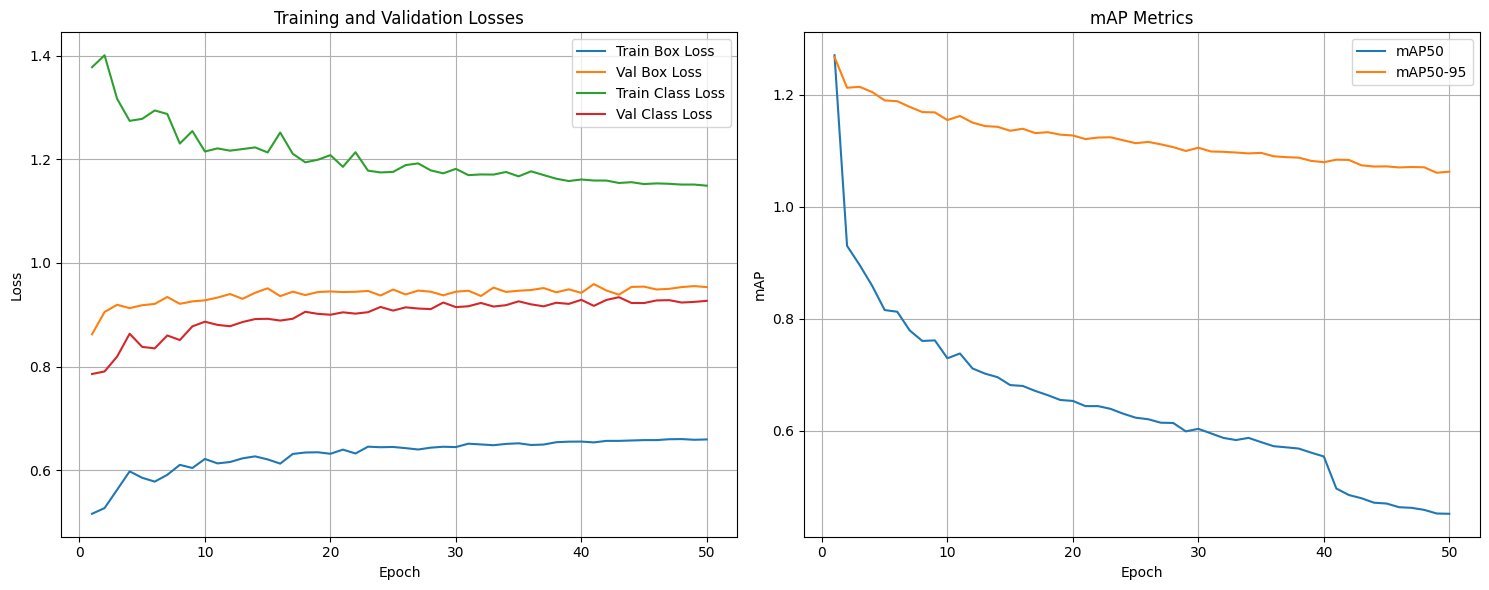

Training metrics visualized successfully.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define the path to the results.csv file
results_path = '/content/runs/detect/Project1/YOLOv8_model/results.csv'

# Adjust the path if the model name was appended with -2 (due to rerunning without changing 'name')
# This check is for robustness in case 'YOLOv8_model' became 'YOLOv8_model-2' etc.
# A more robust way would be to get the actual save_dir from the 'results' object if it exposes it.
# For now, let's assume it's either YOLOv8_model or YOLOv8_model-2 based on previous execution logs.
if not os.path.exists(results_path):
    results_path = '/content/runs/detect/Project1/YOLOv8_model-2/results.csv'

if os.path.exists(results_path):
    # Read the results CSV into a pandas DataFrame
    # Skip the first row as it contains header comments from Ultralytics
    df_results = pd.read_csv(results_path)

    # Rename columns for easier access and cleaner plotting
    df_results.columns = [
        'epoch', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
        'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
        'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'labels', 'lr/pg0',
        'lr/pg1', 'lr/pg2'
    ]

    # Plotting training and validation losses
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.plot(df_results['epoch'], df_results['train/box_loss'], label='Train Box Loss')
    plt.plot(df_results['epoch'], df_results['val/box_loss'], label='Val Box Loss')
    plt.plot(df_results['epoch'], df_results['train/cls_loss'], label='Train Class Loss')
    plt.plot(df_results['epoch'], df_results['val/cls_loss'], label='Val Class Loss')
    plt.title('Training and Validation Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plotting mAP metrics
    plt.subplot(1, 2, 2)
    plt.plot(df_results['epoch'], df_results['metrics/mAP50(B)'], label='mAP50')
    plt.plot(df_results['epoch'], df_results['metrics/mAP50-95(B)'], label='mAP50-95')
    plt.title('mAP Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("Training metrics visualized successfully.")
else:
    print(f"Error: results.csv not found at {results_path}")

Running inference on: /content/dataset/images/test/005482_jpg.rf.4fb61aadf28e0da42a6e02295288498d.jpg

image 1/1 /content/dataset/images/test/005482_jpg.rf.4fb61aadf28e0da42a6e02295288498d.jpg: 640x640 1 head, 7.0ms
Speed: 1.4ms preprocess, 7.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2
Predicted image saved at: /content/runs/detect/predict-2/005482_jpg.rf.4fb61aadf28e0da42a6e02295288498d.jpg


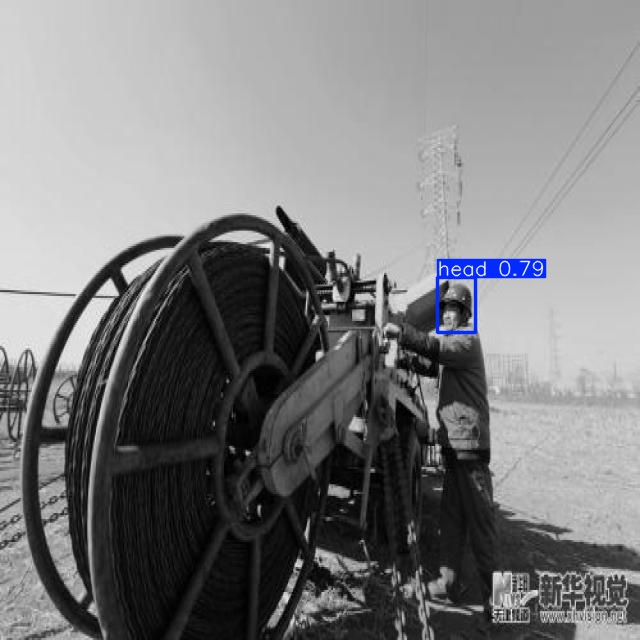

In [16]:
import glob
import random
from IPython.display import Image, display
import os

# Load the best trained model
model_path = '/content/runs/detect/Project1/YOLOv8_model-2/weights/best.pt'
inference_model = YOLO(model_path)

# Get a list of test images
test_images_path = '/content/dataset/images/test'
image_files = glob.glob(os.path.join(test_images_path, '*.jpg')) # Assuming JPG images

if image_files:
    # Pick a random image from the test set for inference
    random_image_path = random.choice(image_files)
    print(f"Running inference on: {random_image_path}")

    # Run inference on the selected image
    # save=True will save the prediction results (image with bounding boxes) to a 'predict' folder
    results = inference_model.predict(source=random_image_path, save=True, conf=0.25, iou=0.7)

    # Display the result image
    # The predicted image is saved in the directory returned by results[0].save_dir
    if results and len(results) > 0:
        save_directory = results[0].save_dir
        result_image_path = os.path.join(save_directory, os.path.basename(random_image_path))

        print(f"Predicted image saved at: {result_image_path}")
        display(Image(filename=result_image_path, width=600))
    else:
        print("No results found for inference.")

    # You can also print the detailed results
    # for r in results:
    #     print(r.boxes)
    #     print(r.probs)
else:
    print(f"No images found in {test_images_path} for inference.")

In [17]:
from google.colab import files

# Define the path to the results.csv file
results_path = '/content/runs/detect/Project1/YOLOv8_model-2/results.csv'

if os.path.exists(results_path):
    files.download(results_path)
    print(f"Downloading {results_path}")
else:
    print(f"Error: The file {results_path} does not exist. Please check the path.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from google.colab import drive
drive.mount('/content/drive')        # Device MOUNTING


Mounted at /content/drive


### 1. Flask Application Structure
To build a Flask app for YOLOv8, you need to:
1.  **Install Flask**: `pip install Flask`.
2.  **Load the Model**: Initialize the YOLO model with your `best.pt` weights.
3.  **Create an Endpoint**: Define a route that handles image uploads and returns predictions.

In [20]:
flask_app_code = """
from flask import Flask, request, jsonify
from ultralytics import YOLO
import io
from PIL import Image

app = Flask(__name__)

# 1. Load your trained model
# Make sure best.pt is in the same folder as this script
model = YOLO('best.pt')

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({'error': 'no image provided'}), 400

    file = request.files['image']
    image_bytes = file.read()
    img = Image.open(io.BytesIO(image_bytes))

    # 2. Run Inference
    results = model(img)

    # 3. Format results to JSON
    predictions = []
    for r in results:
        for box in r.boxes:
            predictions.append({
                'class': r.names[int(box.cls)],
                'confidence': float(box.conf),
                'bbox': box.xyxy.tolist()
            })

    return jsonify({'predictions': predictions})

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)
"""

with open('app.py', 'w') as f:
    f.write(flask_app_code)

print("Created app.py template.")

Created app.py template.


### 2. Deployment Steps
Since you are in Colab, you can download the weights and the app script to your local machine:
1. Download `best.pt` from `/content/runs/detect/Project1/YOLOv8_model-2/weights/best.pt`.
2. Download the `app.py` we just created.
3. Run `python app.py` locally after installing dependencies.

In [21]:
from google.colab import files
# Download the weights and the app script
files.download('/content/runs/detect/Project1/YOLOv8_model-2/weights/best.pt')
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>